In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

df = pd.read_csv('C:/Users/asus/Desktop/HR_Attrition_Project/Data/HR-Employee-Attrition.csv')

print(df.shape)             # how many rows & columns
print(df.dtypes)            # column data types
print(df.isnull().sum())    # any missing values?
df.head()                   # first 5 rows

(1470, 35)
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
Tra

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# TARGET variable — Attrition: "Yes" or "No" — did the employee leave?

# KEY columns to explore:
# Age, Department, JobRole, JobLevel
# MonthlyIncome, YearsAtCompany, YearsWithCurrManager
# OverTime (Yes/No), WorkLifeBalance (1-4)
# JobSatisfaction (1-4), EnvironmentSatisfaction (1-4)

print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True).mul(100).round(1))

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


In [4]:
# 1. Convert Attrition to binary for calculations

df["Attrition_Flag"] = (df["Attrition"] == "Yes").astype(int)


In [34]:
# 2. Income bracket

labels=['Low', 'Mid', 'High', 'Very High']
df["Income_band"] = pd.qcut(df["MonthlyIncome"], q=4, labels = labels)

In [36]:
#3. Tenure Group

bins = [-1, 2, 5 , 10, 40]
labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
df["Tenure_Group"] = pd.cut(df["YearsAtCompany"], bins = bins, labels = labels)

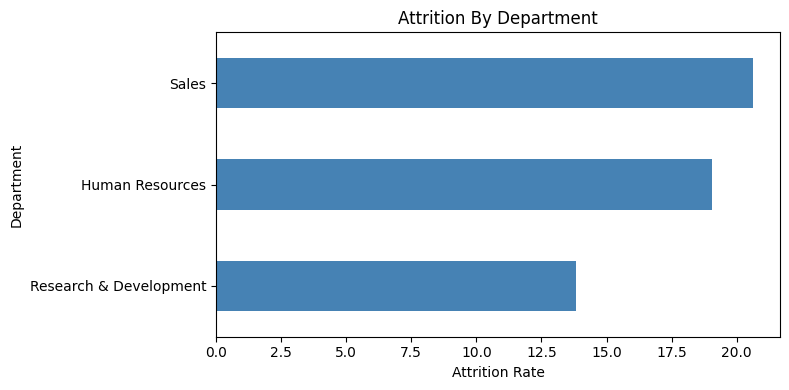

In [6]:
# Chart 1: Attrition by Department

dep_attr = df.groupby("Department")["Attrition_Flag"].mean().mul(100).sort_values()
dep_attr.plot(kind = 'barh', color = 'steelblue', figsize = (8,4))
plt.title("Attrition By Department")
plt.xlabel("Attrition Rate")
plt.tight_layout()
plt.show()

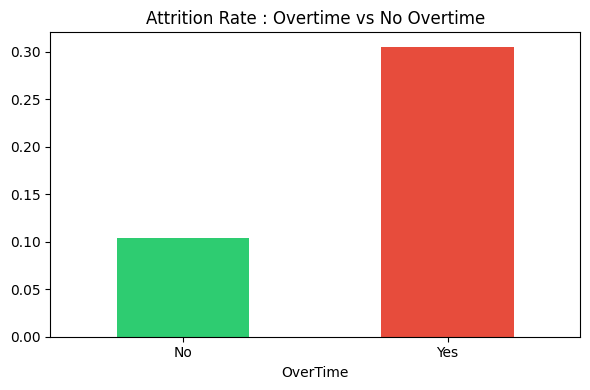

In [47]:
# Chart 2: Overtime vs Attrition

ot = df.groupby("OverTime")["Attrition_Flag"].mean()
ot.plot(kind = 'bar', color = ['#2ecc71','#e74c3c'], figsize = (6,4))
plt.title("Attrition Rate : Overtime vs No Overtime")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

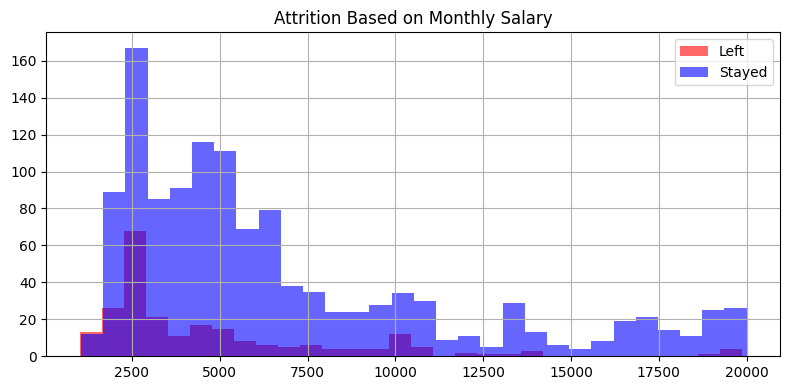

In [55]:
# Chart 3: Income distribution — leavers vs stayers

leavers = df[df["Attrition"] == "Yes"]["MonthlyIncome"]
stayers = df[df["Attrition"] == "No"]["MonthlyIncome"]
plt.figure(figsize = (8,4))
leavers.hist(bins = 30, alpha = 0.6, label = "Left", color = 'red')
stayers.hist(bins = 30, alpha = 0.6, label = "Stayed", color = 'blue')
plt.title("Attrition Based on Monthly Salary")
plt.legend()
plt.tight_layout()
plt.show()

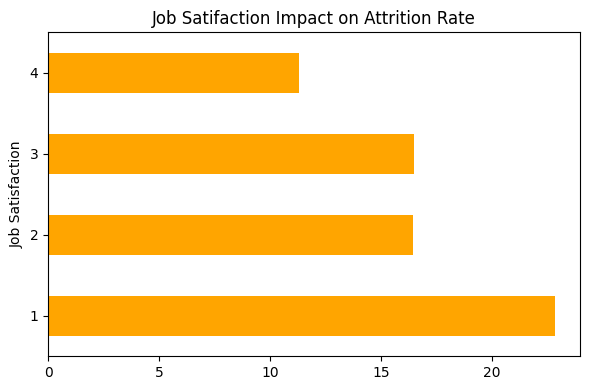

In [63]:
# Chart 4: Job Satisfaction vs Attrition

js = df.groupby("JobSatisfaction")["Attrition_Flag"].mean().mul(100)
js.plot(kind = 'barh', color = 'orange', figsize = (6,4))
plt.title("Job Satifaction Impact on Attrition Rate")
plt.ylabel("Job Satisfaction")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

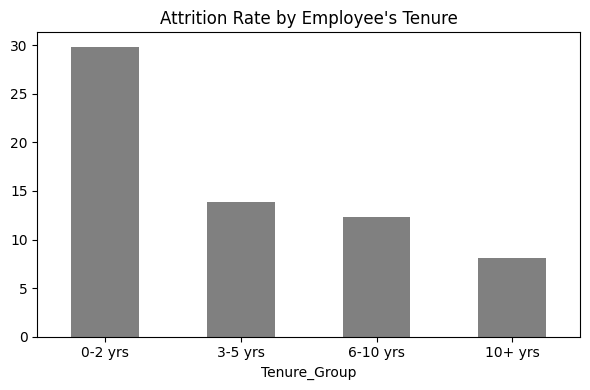

In [64]:
# Chart 5: Attrition by Years at Company

tenure = df.groupby("Tenure_Group")["Attrition_Flag"].mean().mul(100)
tenure.plot(kind = 'bar', color = 'grey', figsize = (6,4))
plt.title("Attrition Rate by Employee's Tenure")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [70]:
df.to_csv("HR-Employee-Attrition-new.csv")